# Healthcare Cybersecurity through Reinforcement Learning

DeepGuard Inc., a leading company in the field of cybersecurity for healthcare industries, is facing an increase in the complexity and sophistication of cyberattacks. The need to protect sensitive patient information and ensure regulatory compliance is crucial to maintaining customer trust and data security.

****Project Benefits****: The implementation of advanced Reinforcement Learning algorithms to simulate and mitigate attack and defense scenarios offers significant advantages:

- ****Improved Defense****: Training defensive agents in simulated scenarios to develop robust and adaptable protection strategies.

- ****Vulnerability Identification****: Simulating attacks to identify and address vulnerabilities in network systems before they can be exploited by real attackers.

- ****Technological Innovation****: Using advanced Reinforcement Learning techniques to promote innovation and continuously improve cybersecurity defense capabilities.

- ****Resource Optimization****: Automating the simulation of attacks and defenses to reduce human workload and optimize the allocation of company resources.

****Project Details****: GreenGuard Solutions commissioned the development of an advanced cybersecurity solution based on Reinforcement Learning algorithms. The project focuses on applying two main algorithms within the gym-idsgame environment, specialized in attack and defense simulations in computer networks.

****Project Objectives****:

1.  ****SARSA Algorithm****: Use SARSA to address "random attack" scenarios in the gym-idsgame environment.

2.  ****DDQN Algorithm****: Implement Double Deep Q-Network (DDQN) with PyTorch to solve "random attack" and "maximal attack" scenarios.

****Deliverable****: The project requires the submission of a Google Colab notebook divided into two main sections, each dedicated to one of the two Reinforcement Learning algorithms. Each section must contain detailed explanations of the proposed solutions, providing justification for the choices made and analyzing the results obtained.

****Project Motivation****: GreenGuard Solutions places the highest priority on cybersecurity in the healthcare sector. The use of advanced Reinforcement Learning algorithms to simulate and mitigate cyber risks allows the company to strengthen its defensive capabilities and protect computer networks against increasingly sophisticated attacks. By automating attack simulations, GreenGuard optimizes operational efficiency and establishes itself as a leader in technological innovation for cybersecurity in the healthcare sector.

****Simulation Environment Link****: https://github.com/Limmen/gym-idsgame

****Guide to correctly set up the environment****: https://colab.research.google.com/drive/15nTl0CSLuSaO_4rQg3eLQXrtfE6qvjYW?usp=sharing

With this project, GreenGuard Solutions aims to ensure the security of sensitive patient data and maintain the integrity of information in the healthcare context, protecting computer networks from increasingly advanced and persistent cyber threats.

# Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import numpy as np
import os
import gc

In [ ]:
# Random seed for reproducibility
SEED = 42

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# more reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
do_debug = False

In [ ]:
# Function to clean cache
def cache_cleaner():
  gc.collect()
  torch.cuda.empty_cache()

## New releases adaptation guide

In [ ]:
!pip install scikit-learn
!pip install --no-deps gym-idsgame

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.8/452.8 kB 14.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for gym-idsgame: filename=gym_idsgame-1.0.13-py3-none-any.whl size=969599 sha256=54b59ddc0eb86b16cf2afeecb91c4a74dad7b868e6abfb0b20747b8fd84ddcf1
  Stored in directory: /root/.cache/pip/wheels/bb/cd/79/f439cc0b004b731a95ba5d840771ebca2bc9f8c958fcb91463
Successfully built gym-idsgame


### Fix: missing import in bot agent

Library has a bug: file `random_attack_bot_agent.py` and `attack_maximal_value_bot_agent.py` use `idsgame_util` without importing it, causing a `NameError` at the first `step()`. We solve it with a monkey-patch: we inject hte missing module into the bot agents' scope.

This fix is needed only if the environment decides to call internally the bot agent. In our wrapper we'll pass a placeholder (`-1`) as attacking move to prevent the bot from being called, but the patch remains as security net.

In [ ]:
import gym_idsgame.envs.util.idsgame_util as _idsgame_util
import gym_idsgame.agents.bot_agents.random_attack_bot_agent as _random_bot
import gym_idsgame.agents.bot_agents.attack_maximal_value_bot_agent as _maximal_bot

if not hasattr(_random_bot, 'idsgame_util'):
    _random_bot.idsgame_util = _idsgame_util
    print("Patch applied: random_attack_bot_agent")

if not hasattr(_maximal_bot, 'idsgame_util'):
    _maximal_bot.idsgame_util = _idsgame_util
    print("Patch applied: attack_maximal_value_bot_agent")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

Patch applicata: random_attack_bot_agent
Patch applicata: attack_maximal_value_bot_agent


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Environment creation

In [ ]:
from gym_idsgame.envs import IdsGameRandomAttackV21Env
env = IdsGameRandomAttackV21Env()

# DefenderWrapper

In [ ]:
import numpy as np

class DefenderWrapper:
    """
    Wrapper that adapts gym-idsgame for the single-agent (defender).
    The attacker is managed by the environment's internal bot.
    """
    def __init__(self, env):
        self.env = env
        self.action_space = env.defender_action_space

    def reset(self):
        obs = self.env.reset()
        # reset() returns (attacker_obs, defender_obs)
        if isinstance(obs, tuple):
            obs = obs[1]
        return obs.flatten()

    def step(self, action):
        # We pass a random action (!= -1) to activate the attacker bot
        attacker_action = self.env.attacker_action_space.sample()
        res = self.env.step((attacker_action, action))

        obs, reward, done = res[0], res[1], res[2]
        info = res[3] if len(res) > 3 else {}

        # We are extracting only the defender's part
        if isinstance(obs, tuple):
            obs = obs[1]
        if isinstance(reward, tuple):
            reward = reward[1]

        return obs.flatten(), reward, done, info

# Test everything is working

In [ ]:
from gym_idsgame.envs import IdsGameRandomAttackV21Env, IdsGameMaximalAttackV21Env

# --- Random Attack ---
raw_env = IdsGameRandomAttackV21Env()
env = DefenderWrapper(raw_env)

obs = env.reset()
if do_debug:
  print(f"Initial observation: shape={obs.shape}, dtype={obs.dtype}")
  print(f"Defender's actions number: {env.action_space.n}")

# Let's do 5 random steps
for i in range(5):
    action = env.action_space.sample()
    obs, reward, done, info = env.step(action)
    print(f"  Step {i+1}: reward={reward}, done={done}, obs_shape={obs.shape}")
    if done:
        break

print("\nRandom Attack: OK!")

  Step 1: reward=0, done=False, obs_shape=(20,)
  Step 2: reward=0, done=False, obs_shape=(20,)
  Step 3: reward=0, done=True, obs_shape=(20,)

Random Attack: OK!


In [ ]:
# --- Maximal Attack ---
raw_env_max = IdsGameMaximalAttackV21Env()
env_max = DefenderWrapper(raw_env_max)

obs = env_max.reset()
if do_debug:
  print(f"Initial observation: shape={obs.shape}, dtype={obs.dtype}")
  print(f"Defender's actions number: {env_max.action_space.n}")

for i in range(5):
    action = env_max.action_space.sample()
    obs, reward, done, info = env_max.step(action)
    print(f"  Step {i+1}: reward={reward}, done={done}")
    if done:
        break

print("\nMaximal Attack: OK!")

  Step 1: reward=0, done=False
  Step 2: reward=0, done=False
  Step 3: reward=0, done=False
  Step 4: reward=0, done=False
  Step 5: reward=0, done=True

Maximal Attack: OK!


# Baseline

In [ ]:
def random_baseline(env, n_episodes=500, max_steps=100):
    wins, losses = 0, 0
    total_rewards = []

    for _ in range(n_episodes):
        obs = env.reset()
        done = False
        ep_reward = 0
        steps = 0

        while not done and steps < max_steps:
            action = env.action_space.sample()
            obs, reward, done, info = env.step(action)
            ep_reward += reward
            steps += 1

        total_rewards.append(ep_reward)
        if ep_reward > 0:
            wins += 1
        elif ep_reward < 0:
            losses += 1

    print(f"Episodes: {n_episodes}")
    print(f"Defender wins: {wins} ({wins/n_episodes*100:.1f}%)")
    print(f"Attacker wins: {losses} ({losses/n_episodes*100:.1f}%)")
    print(f"Avg reward: {np.mean(total_rewards):.3f} ± {np.std(total_rewards):.3f}")

print("=== Baseline Random Attack ===")
env_ra = DefenderWrapper(IdsGameRandomAttackV21Env())
random_baseline(env_ra)

print("\n=== Baseline Maximal Attack ===")
env_ma = DefenderWrapper(IdsGameMaximalAttackV21Env())
random_baseline(env_ma)

=== Baseline Random Attack ===
Episodi: 500
Vittorie difensore: 3 (0.6%)
Vittorie attaccante: 254 (50.8%)
Reward medio: -13.200 ± 13.003

=== Baseline Maximal Attack ===
Episodi: 500
Vittorie difensore: 0 (0.0%)
Vittorie attaccante: 314 (62.8%)
Reward medio: -16.328 ± 12.567


# Implementation: begin

## 7. Ready to implement

At this point you have:
- The environment installed and working
- A wrapper that gives you a single-agent standard interface
- A random baseline as reference

The wrapper interface is Gym's classic one:

```python
obs = env.reset()              # array numpy flattened
obs, reward, done, info = env.step(action)  # action is an integer
n_actions = env.action_space.n # number of available actions
```

You can directly use it with SARSA (converting `obs` into a tuple for Q-table) or with DDQN (converting `obs` into a PyTorch tensor for the neural net).

**Good luck!**

# Project Solution:

**Disclaimer**:
I choose to keep the previous Baseline untouched instead of optimize any parameter for two main reason:
- The Baseline came as part of the task (guide),
- It can be used to point out some aspects later on (example: episoded number of Baseline is too low to be efficient for a DDQN, keeping it low at 500 helps to show this aspect of working with DDQNs).


# SARSA

For SARSA I'll be useing a Python dictionary Q-table to handle the large state space efficiently.

States are initialized dynamically upon visitation, saving memory and focusing on actually explored configurations.


In [ ]:
def get_q_value(Q, state_key, action, n_actions):
    """Dynamically initialize state actions at zero"""
    if state_key not in Q:
        Q[state_key] = np.zeros(n_actions)

    return Q[state_key][action]

def get_max_q_action(Q, state_key, n_actions):
    """Action with max value per state."""
    if state_key not in Q:
        Q[state_key] = np.zeros(n_actions)
    return np.argmax(Q[state_key])

def choose_action(state_key, Q, epsilon, n_actions):
    """Epsilon-greedy policy with dict keys."""
    if np.random.uniform(0, 1) < epsilon:
        return np.random.choice(n_actions)
    else:
        return get_max_q_action(Q, state_key, n_actions)

In [ ]:
def shape_reward_sarsa(reward):
    if reward == 1:
      reward = 25
    elif reward < -5:
      reward = -2
    else:
      reward = 0.1

    return reward

### Reward shaping SARSA:
These values have been obtained through various experiments.

What I noticed during this tests is that:
- strongly supporting victories,
- reducing the effect of strong losses,
- and a small positive reward when the defender "ties" (neither the defender nor the attacker wins).

Led to the best results.

Reducing penalties is used to avoid aggressive updates of the Q-table while "ties" have a small positive reward to support exploration.

Even though the big gap between win and loss rewards could be dangerous, leading to an overstimation of lucky moves, the results obtained don't seems to show this kind of problem.

In [ ]:
def state_to_key(state):
    return tuple(np.clip(state, 0, 2).astype(int))

In [ ]:
from math import e
def sarsa(wrapped_env, alpha, gamma, epsilon, episodes, max_steps):
    wins, losses = 0, 0
    total_rewards = []

    Q = {}
    n_actions = wrapped_env.action_space.n
    wrapped_env.hacked = False

    for episode in range(episodes):
        ep_reward = 0

        flat_state = wrapped_env.reset()
        # state_key = tuple(flat_state)
        state_key = state_to_key(flat_state)


        action = choose_action(state_key, Q, epsilon, n_actions)
        epsilon = max(0.10, epsilon - 0.01)

        for step in range(max_steps):
            next_flat_state, reward, done, info = wrapped_env.step(action)
            # next_state_key = tuple(next_flat_state)
            next_state_key = state_to_key(next_flat_state)

            # Reward shaping
            reward = shape_reward_sarsa(reward)

            next_action = choose_action(next_state_key, Q, epsilon, n_actions)

            # Extract values and SARSA update
            current_q = get_q_value(Q, state_key, action, n_actions)

            # Dynamically initialize next state before exists
            if next_state_key not in Q:
                Q[next_state_key] = np.zeros(n_actions)

            # td_target = reward + gamma * Q[next_state_key][next_action]
            if done:
                td_target = reward
            else:
                td_target = reward + gamma * Q[next_state_key][next_action]
            td_error = td_target - current_q
            Q[state_key][action] += alpha * td_error
            # print(f"REWARD >> {reward} | EP >> {episode}")
            # Reward for each step
            ep_reward += reward

            flat_state = next_flat_state
            state_key = next_state_key
            action = next_action

            if done:
                break


        if episode % 100 == 0 and do_debug:
            print(f"Episode: {episode} | Defender wins: {wins} ({wins/episodes*100:.1f}% VS Attacker wins: {losses} ({losses/episodes*100:.1f}%)")

        # update total reward for this episode
        total_rewards.append(ep_reward)

        # Episode winner/loser
        if ep_reward > 0:
            wins += 1
        else:
            losses += 1


    # Show results
    if do_debug:
        print(f"LEN Q >> {len(Q)}")
    print(f"Episodes: {episodes}")
    print(f"Defender wins: {wins} ({wins/episodes*100:.1f}%)")
    print(f"Attacker wins: {losses} ({losses/episodes*100:.1f}%)")
    print(f"Reward avg: {np.mean(total_rewards):.3f} ± {np.std(total_rewards):.3f}")

    return Q

In [ ]:
def evaluate_sarsa(wrapped_env, Q, episodes=500, max_steps=100):
    """
    Evaluate Q-table SARSA without exploration (policy greedy).
    Returns wins, losses, episode_results
    """
    wins, losses = 0, 0
    total_rewards = []
    episode_results = []

    unknown_states = 0
    known_states = 0


    wrapped_env.hacked = False
    n_actions = wrapped_env.action_space.n

    for episode in range(episodes):
        ep_reward = 0

        flat_state = wrapped_env.reset()
        state_key = state_to_key(flat_state)

        for step in range(max_steps):
            # Action greedy (Epsilon = 0 implicit)
            if state_key not in Q:
                unknown_states += 1
                action = wrapped_env.action_space.sample()
            else:
                known_states += 1
                action = np.argmax(Q[state_key])

            next_flat_state, reward, done, info = wrapped_env.step(action)

            # Reward shaping
            reward = shape_reward_sarsa(reward)

            ep_reward += reward

            flat_state = next_flat_state
            next_state_key = state_to_key(next_flat_state)
            state_key = next_state_key

            if done:
                break

        # reward count
        total_rewards.append(ep_reward)

        # win/loss
        if ep_reward > 0:
            wins += 1
            episode_results.append(1)
        else:
            losses += 1
            episode_results.append(0)

    # Show results
    print("=== SARSA Evaluation ===")
    if do_debug:
        print(f"NOTE >> Unknown states {unknown_states} | Known states {known_states}")
    print(f"Episodes: {episodes}")
    print(f"Defender wins: {wins} ({wins/episodes*100:.1f}%)")
    print(f"Attacker wins: {losses} ({losses/episodes*100:.1f}%)")
    print(f"Reward avg: {np.mean(total_rewards):.3f} ± {np.std(total_rewards):.3f}")

    return wins, losses, episode_results


## Random Attack: SARSA

In [ ]:
# --- Random Attack ---
raw_env = IdsGameRandomAttackV21Env()
env = DefenderWrapper(raw_env)

In [ ]:
# Default values same as Baseline
alpha = 0.1  # Learning rate
gamma = 0.995  # Discount factor
epsilon = 0.6 # Exploration rate
episodes = 2000 # default: 500
max_steps = 100 # default: 100

Q_table_dict = sarsa(env, alpha, gamma, epsilon, episodes, max_steps)

Episodes: 2000
Defender wins: 1086 (54.3%)
Attacker wins: 914 (45.7%)
Reward avg: 4.135 ± 10.139


In [ ]:
wins, losses, episode_results_sarsa = evaluate_sarsa(
    env_ra,
    Q_table_dict,
    episodes=500
)

=== SARSA Evaluation ===
Episodes: 500
Defender wins: 296 (59.2%)
Attacker wins: 204 (40.8%)
Reward avg: 8.028 ± 12.409


# Comments SARSA
The results show an improvement over the completely random policy of the baseline.

SARSA learns a strategy that increases the defender's win rate, showing that the Q-table is effectively saving useful information about state-action.

In the end, SARSA represents a fairly good solution to solve Random Attack but its performance still suffers when the complexity of the state grows (most complex aspect I faced).

# DDQN

In [ ]:
def shape_reward_ddqn(reward):
    if reward == 1:
      reward = 50
    elif reward < -5:
      reward = -2
    else:
      reward = 1

    return reward

### Reward shaping DDQN:
For DDQN's rewards I maintained the same philophy used for SARSA: strongly support victories, reduced the impact of losses and supported "ties" with a small reward.

In this case, what I changed compared to SARSA is an even more aggressive reward for wins and "ties".

As before, these values have been obtained through various experiments (starting from the SARSA's implementation of rewards and then updated based on the results obtained by DDQN).

NOTE: I used the same reward shaping for Random and Maximal Attack for two main reasons:
1. During my tests, I noticed that it was working quite well for both and when I tried to update it for Maximal Attack I was not able to have relevant better results,
2. Based on what I've mentioned in point 1. , I finally choose to keep it the same for both to have a small comparison between tasks using the same reward system.

In [ ]:
# Replay Buffer
class ReplayBuffer:

    def __init__(self, capacity):
        self.buffer = deque(maxlen = capacity) # deque in order to forget the oldest memory when full and not the newest


    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer,batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        """"The zip(*batch) command takes the list of sampled random tuples and "rotates" it.
        It separates all states into one list, all actions into another, all rewards into yet another, and so on."""

        # convert into NumPy vectors to work with torch.Tensor
        return ( np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(dones) )


    def __len__(self):
        return len(self.buffer)


# Neural Network Q Function
class DQN(nn.Module):
    # output_dim is equal to num_actions
    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.05), # to decrease overfitting risk

            nn.Linear(512, 256),
            nn.LeakyReLU(0.1),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.1),

            nn.Linear(128, output_dim)
        )

    def forward(self,x):
        return self.net(x)


# DDQN Agent
class DDQNAgent:
    def __init__(self, state_dim, action_dim, lr, gamma):
        self.gamma = gamma
        self.action_dim = action_dim
        self.lr = lr

        self.online_net = DQN(state_dim, action_dim)
        self.target_net = DQN(state_dim, action_dim)

        self.target_net.load_state_dict(self.online_net.state_dict())
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(100000)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.online_net.to(self.device)
        self.target_net.to(self.device)

    def act(self, state, epsilon):
        if random.random() < epsilon:
            return random.randrange(self.action_dim)

        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.online_net(state)
        return q_values.argmax(1).item()

    # update target network
    def update_target(self):
        self.target_net.load_state_dict(
            self.online_net.state_dict()
        )

    # training step
    def train_step(self, batch_size):
        # if buffer not ready None
        if len(self.memory) < batch_size:
            return None

        states, actions, rewards, next_states, dones = self.memory.sample(batch_size)
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)

        # Check 'done' is boolean
        if isinstance(dones, np.ndarray) and dones.dtype == bool:
            dones = torch.FloatTensor(dones.astype(float)).to(self.device)
        else:
            dones = torch.FloatTensor(dones).to(self.device)

        # Check that current_q and target_q have the same dimensions.
        current_q = self.online_net(states).gather(1, actions.unsqueeze(1)).squeeze()

        with torch.no_grad():
            next_actions = self.online_net(next_states).argmax(1)
            next_q = self.target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze()
            target_q = rewards + (self.gamma * next_q * (1 - dones))

        loss = nn.SmoothL1Loss()(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=1.0)

        self.optimizer.step()

        return loss.item()  # Numeric loss value


# Training Loop DDQN
def train_ddqn(env, episodes=500, max_steps=100, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.01, batch_size=64, lr=0.01, gamma=0.99):
    state_dim = env.reset().shape[0]
    action_dim = env.action_space.n

    agent = DDQNAgent(state_dim, action_dim, lr, gamma)

    rewards_history = []
    wins, losses = 0, 0

    # Avg loss episode
    ep_losses = []

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0
        ep_losses.clear()

        for step in range(max_steps):
            action = agent.act(state, epsilon)
            next_state, reward, done, _ = env.step(action)

            # Reward shaping
            reward = shape_reward_ddqn(reward)

            agent.memory.push(state, action, reward, next_state, done)

            # Loss value at each step
            loss_val = agent.train_step(batch_size)
            if loss_val is not None:
                ep_losses.append(loss_val)

            state = next_state
            total_reward += reward

            if np.any(done):  # safe check for 'done' (against gym-idsgame's array)
                break

        # old_epsilon used to check epsilon evolution for debugging porpouse
        old_epsilon = epsilon
        # epsilon = max(epsilon_min, epsilon - epsilon_decay)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        # if ep % 10 == 0:
        if ep % 50 == 0:
            agent.update_target()

        # Avg loss update (ep_losses) plus debug prints
        if ep % 20 == 0:
            avg_loss = np.mean(ep_losses) if ep_losses else 0.0
            if do_debug:
                print(f"\n--- DIAGNOSTIC EPISODE {ep} ---")
                print(f"-> Epsilon: {old_epsilon:.4f} -> {epsilon:.4f}")
                print(f"-> Last episod Total Reward: {total_reward}")
                print(f"-> Avg Loss gradients: {avg_loss:.6f}")
                print(f"-> Actual memory dimension: {len(agent.memory)}/{batch_size}")
                print(f"-> Actual Defender Wins: {wins} | Losses: {losses}")
                print("---------------------------------\n")

        rewards_history.append(total_reward)

        if total_reward > 0:
            wins += 1
        else:
            losses += 1

    # Show results
    print(f"Episodes: {episodes}")
    print(f"Defender wins: {wins} ({wins/episodes*100:.1f}%)")
    print(f"Attacker wins: {losses} ({losses/episodes*100:.1f}%)")
    print(f"Reward avg: {np.mean(rewards_history):.3f} ± {np.std(rewards_history):.3f}")

    return agent, rewards_history


In [ ]:
def evaluate_ddqn(agent, env, episodes=500, max_steps=100):
    """
    Evaluate DDQN agent without exploration (greedy policy, epsilon=0).
    Returns wins, losses, episode_results
    """
    rewards = []
    wins = 0
    losses = 0

    episode_results = [] # to plot

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0

        for step in range(max_steps):
            # Action pure greedy (Epsilon = 0)
            action = agent.act(state, epsilon=0)

            next_state, reward, done, _ = env.step(action)

            # Reward shaping
            reward = shape_reward_ddqn(reward)

            total_reward += reward
            state = next_state

            if np.any(done):
                break

        rewards.append(total_reward)

        # Win/loss
        if total_reward > 0:
            wins += 1
            episode_results.append(1)
        else:
            losses += 1
            episode_results.append(0)

    # Show results
    print(f"\n=== DDQN Evaluation ===")
    print(f"Evaluation episodes: {episodes}")
    print(f"Defender wins: {wins} ({wins/episodes*100:.1f}%)")
    print(f"Attacker wins: {losses} ({losses/episodes*100:.1f}%)")
    print(f"Reward avg: {np.mean(rewards):.3f} ± {np.std(rewards):.3f}")

    return wins, losses, episode_results


## Random Attack: DDQN

In [ ]:
episodes = 1000
max_steps = 100
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.994
batch_size = 64
lr = 0.0001
gamma = 0.99

env_ddqn_random = DefenderWrapper(IdsGameRandomAttackV21Env())
agent_random, history_random = train_ddqn(env_ddqn_random,
                                          episodes=episodes,
                                          max_steps=max_steps,
                                          epsilon = epsilon,
                                          epsilon_min = epsilon_min,
                                          epsilon_decay = epsilon_decay,
                                          batch_size = batch_size,
                                          lr = lr,
                                          gamma = gamma)

Episodes: 1000
Defender wins: 858 (85.8%)
Attacker wins: 142 (14.2%)
Reward avg: 3.786 ± 5.368


### Evaluate Random DDQN

In [ ]:
episodes = 500
wins, losses, episode_results_ddqn_random = evaluate_ddqn(agent_random, env_ddqn_random, episodes=episodes)


=== DDQN Evaluation ===
Evaluation episodes: 500
Defender wins: 438 (87.6%)
Attacker wins: 62 (12.4%)
Reward avg: 4.018 ± 3.804


# Comments on DDQN: Random Attack
For the Random Attack case, I choose (again, based on experimentation) values for hyper-parameters that initially support exploration in order to face as much situations as possible.

While the low learning rate helps prevent to have too much unstablity for weight updates.

## Maximal Attack: DDQN

In [ ]:
episodes = 1000
max_steps = 100
epsilon = 0.6
epsilon_min = 0.065#0.05
epsilon_decay = 0.994
batch_size = 64
lr = 0.0001
gamma = 0.99

env_ddqn_max = DefenderWrapper(IdsGameMaximalAttackV21Env())
agent_max, history_max = train_ddqn(env_ddqn_max,
                                    episodes=episodes,
                                    max_steps=max_steps,
                                    epsilon = epsilon,
                                    epsilon_min = epsilon_min,
                                    epsilon_decay = epsilon_decay,
                                    batch_size = batch_size,
                                    lr = lr,
                                    gamma = gamma)

Episodes: 1000
Defender wins: 588 (58.8%)
Attacker wins: 412 (41.2%)
Reward avg: 2.031 ± 2.200


### Evaluate Max DDQN

In [ ]:
episodes = 500
wins, losses, episode_results_ddqn_max = evaluate_ddqn(agent_max, env_ddqn_max, episodes=episodes)


=== DDQN Evaluation ===
Evaluation episodes: 500
Defender wins: 311 (62.2%)
Attacker wins: 189 (37.8%)
Reward avg: 2.092 ± 2.165


# Comments DDQN : Maximal Attack
For the Maximal Attack case, I had to use a lower initial epsilon value compared to Random Attack.

I reckon this has been needed because in this scenario the attacker adopts a much more aggressive strategy and too much randomness in the defender's actions leads to worse results.

NOTE: I choose to keep the same episodes and steps number for both Random and Maximal to have a comparison of performances of DDQN against the two attacks.

# Plot evaluations and comments about SARSA - Random Attack, DDQN - Random Attack and DDQN - Maximal Attack

In [ ]:
import matplotlib.pyplot as plt

def plot_cumulative_win_rate(results, title="Defender Win Rate"):

    cumulative_wins = np.cumsum(results)
    episodes = np.arange(1, len(results) + 1)

    win_rate = cumulative_wins / episodes

    plt.figure(figsize=(7,4))
    plt.plot(episodes, win_rate)

    plt.xlabel("Evaluation Episode")
    plt.ylabel("Cumulative Defender Win Rate")
    plt.title(title)
    plt.grid(True)

    plt.show()
    print("\n" *2)

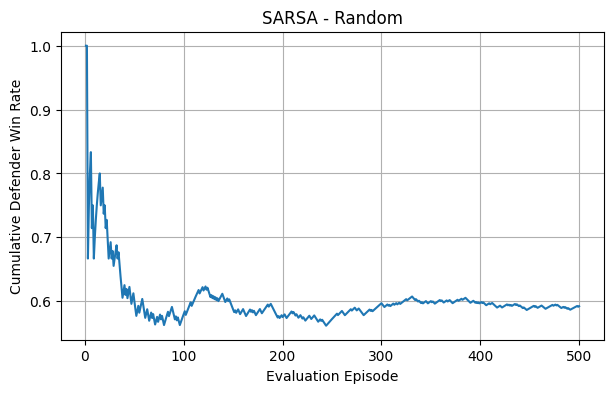

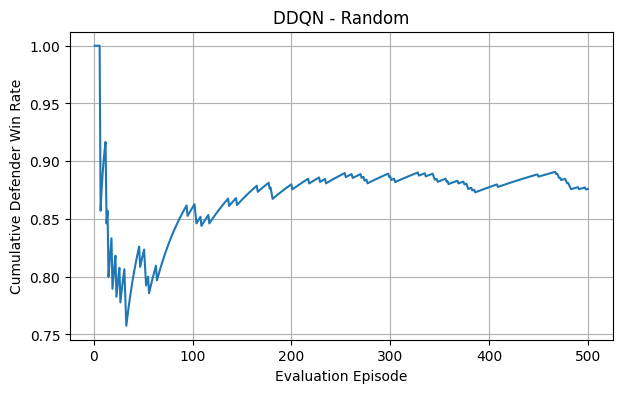

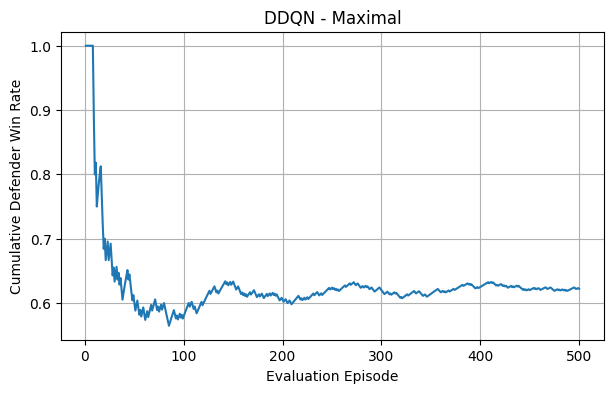

In [ ]:
plot_cumulative_win_rate(
    episode_results_sarsa,
    title="SARSA - Random"
)

plot_cumulative_win_rate(
    episode_results_ddqn_random,
    title="DDQN - Random"
)

plot_cumulative_win_rate(
    episode_results_ddqn_max,
    title="DDQN - Maximal"
)

# Comments to SARSA and DDQN Performances after evaluation

NOTE: The following values can slightly differ during following runs due to the environment's stochastic nature.

- SARSA - Random : train 54.6% | evaluation 57.8% ,
- DDQN - Random : train 87.6% | evaluation 90.8% ,
- DDQN - Maximal : train 60.1% | evaluation 61.5% .

These results shows that the model learned something (with no overfitting) and that the final policies are better then the previous ones during training.

The gap between train and evaluation results is small (in average ~3%), showing stability during the training.

EXTRA NOTE: Performing multiple test runs, I've noticed that DDQN - Maximal in some cases shows a negative performance gap of evaluation against train (~61% train and ~59% evaluation). This ~2% negative gap is not an alarming value but I still consider to write this down for completeness.

# Final comments:
The DDQN algorithm performed better compared to SARSA, primarily due to the neural network's ability to generalize even across state configurations that were not frequently observed during training.

Probably the most relevant aspect (apart from the algorithms themself) is the reward system implemented. Without it the algorithms performance were around 0-2%, while a good reward system has been a game changer for the performance, allowing to reach the actual results, for both SARSA and DDQN.

It also emerged that the choice of epsilon is extremely relevant for the result: in Random Attack high exploration helped leading to more experiences but in Maximal led to ineffective actions due to the more aggressive Attacker.

As final consideration, DDQN is more complex and requires more extensive hyperparameter tuning compared to SARSA, but it offers a more robust and scalable performance thanks to its networks that can generilize across state.